# Mushroom Classification — Numpy Decision Tree from Scratch

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
)

## Data Loading and Preprocessing

In [ ]:
df = pd.read_csv("../data/mushrooms.csv")
df = df.replace("?", np.nan)
df = df.drop(columns=["veil-type"], errors="ignore")

y = df["class"]
X = df.drop(columns=["class"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

y_test_binary = (y_test == "p").astype(int)

In [33]:
categorical_cols = X.columns.tolist()

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_preprocess, categorical_cols)
    ]
)

## Numpy Decision Tree Implementation

In [34]:
class _Node:
    __slots__ = ("feature", "threshold", "left", "right", "is_leaf", "proba", "pred")
    def __init__(self, *, feature=None, threshold=None, left=None, right=None,
                 is_leaf=False, proba=None, pred=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.is_leaf = is_leaf
        self.proba = proba
        self.pred = pred

class NumpyTreeClassifier:
    def __init__(self, criterion="gini", max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, min_gain=0.0, random_state=None):
        if criterion not in ("gini", "entropy"):
            raise ValueError("criterion must be either 'gini' or 'entropy'")
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = int(min_samples_split)
        self.min_samples_leaf = int(min_samples_leaf)
        self.min_gain = float(min_gain)
        self.random_state = random_state
        self.classes_ = None
        self.n_classes_ = None
        self.root_ = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.classes_, y_enc = np.unique(y, return_inverse=True)
        self.n_classes_ = len(self.classes_)
        self.root_ = self._grow(X, y_enc, depth=0)
        return self

    def predict(self, X):
        X = np.asarray(X)
        preds_enc = np.array([self._predict_one(x, self.root_) for x in X], dtype=int)
        return self.classes_[preds_enc]

    def predict_proba(self, X):
        X = np.asarray(X)
        out = np.zeros((X.shape[0], self.n_classes_), dtype=float)
        for i, x in enumerate(X):
            node = self.root_
            while not node.is_leaf:
                if x[node.feature] <= node.threshold:
                    node = node.left
                else:
                    node = node.right
            out[i] = node.proba
        return out

    def _impurity_from_counts(self, counts):
        n = counts.sum()
        if n <= 0:
            return 0.0
        p = counts / n
        if self.criterion == "gini":
            return 1.0 - np.sum(p * p)
        p = p[p > 0]
        return -np.sum(p * np.log2(p))

    def _best_split(self, X, y):
        n, d = X.shape
        if n < self.min_samples_split:
            return None, None, None
        parent_counts = np.bincount(y, minlength=self.n_classes_)
        parent_impurity = self._impurity_from_counts(parent_counts)
        if parent_impurity == 0.0:
            return None, None, None
        best_gain = 0.0
        best_feat = None
        best_thr = None
        for j in range(d):
            xj = X[:, j]
            order = np.argsort(xj, kind="quicksort")
            x_sorted = xj[order]
            y_sorted = y[order]
            if x_sorted[0] == x_sorted[-1]:
                continue
            left_counts = np.zeros(self.n_classes_, dtype=int)
            right_counts = parent_counts.copy()
            for i in range(0, n - 1):
                c = y_sorted[i]
                left_counts[c] += 1
                right_counts[c] -= 1
                left_n = i + 1
                right_n = n - left_n
                if left_n < self.min_samples_leaf or right_n < self.min_samples_leaf:
                    continue
                if x_sorted[i] == x_sorted[i + 1]:
                    continue
                left_imp = self._impurity_from_counts(left_counts)
                right_imp = self._impurity_from_counts(right_counts)
                weighted = (left_n / n) * left_imp + (right_n / n) * right_imp
                gain = parent_impurity - weighted
                if gain > best_gain:
                    best_gain = gain
                    best_feat = j
                    best_thr = 0.5 * (x_sorted[i] + x_sorted[i + 1])
        if best_feat is None or best_gain <= self.min_gain:
            return None, None, None
        mask = X[:, best_feat] <= best_thr
        return best_feat, best_thr, mask

    def _grow(self, X, y, depth):
        counts = np.bincount(y, minlength=self.n_classes_)
        n = y.size
        proba = counts / n
        pred = int(np.argmax(counts))
        impurity = self._impurity_from_counts(counts)
        if (self.max_depth is not None and depth >= self.max_depth) or \
           n < self.min_samples_split or \
           impurity == 0.0:
            return _Node(is_leaf=True, proba=proba, pred=pred)
        feat, thr, mask = self._best_split(X, y)
        if feat is None:
            return _Node(is_leaf=True, proba=proba, pred=pred)
        left = self._grow(X[mask], y[mask], depth + 1)
        right = self._grow(X[~mask], y[~mask], depth + 1)
        return _Node(feature=feat, threshold=thr, left=left, right=right,
                     is_leaf=False, proba=proba, pred=pred)

    def _predict_one(self, x, node):
        while not node.is_leaf:
            node = node.left if x[node.feature] <= node.threshold else node.right
        return node.pred

class SKCompatibleNumpyTree(BaseEstimator, ClassifierMixin):
    def __init__(self, criterion="gini", max_depth=None,
                 min_samples_split=2, min_samples_leaf=1,
                 min_gain=0.0, random_state=None):
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_gain = min_gain
        self.random_state = random_state
        self._model = None

    def fit(self, X, y):
        self._model = NumpyTreeClassifier(
            criterion=self.criterion,
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            min_samples_leaf=self.min_samples_leaf,
            min_gain=self.min_gain,
            random_state=self.random_state
        )
        self._model.fit(X, y)
        self.classes_ = self._model.classes_
        return self

    def predict(self, X):
        return self._model.predict(X)

    def predict_proba(self, X):
        return self._model.predict_proba(X)

class ToDense(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

## Hyperparameter Tuning with GridSearchCV


In [ ]:
pipe_np = Pipeline(steps=[
    ("preprocess", preprocess),
    ("todense", ToDense()),
    ("model", SKCompatibleNumpyTree(random_state=42))
])

param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 10, 20],
    "model__criterion": ["gini", "entropy"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_np = GridSearchCV(
    pipe_np,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid_np.fit(X_train, y_train)

print("Best parameters:", grid_np.best_params_)
print("Best CV F1 (weighted):", grid_np.best_score_)

best_numpy_tree = grid_np.best_estimator_

## Evaluation on the Test Set

In [36]:
np_pred = best_numpy_tree.predict(X_test)
np_proba = best_numpy_tree.predict_proba(X_test)[:, 1]

np_acc = accuracy_score(y_test, np_pred)
np_f1 = f1_score(y_test, np_pred, average="weighted")
np_auc = roc_auc_score(y_test_binary, np_proba)

print(f"Accuracy:      {np_acc:.4f}")
print(f"F1 (weighted): {np_f1:.4f}")
print(f"ROC-AUC:       {np_auc:.4f}")

Accuracy:      0.9988
F1 (weighted): 0.9988
ROC-AUC:       0.9990


## Comparison with Sklearn

In [37]:
# Sklearn results from mushroom_eda_sklearn_tree.ipynb
# Best GridSearchCV model evaluated on the same test set
sk_acc = 1.0
sk_f1  = 1.0
sk_auc = 1.0

results = pd.DataFrame({
    "Model": ["Sklearn DecisionTree", "Numpy DecisionTree"],
    "Accuracy": [sk_acc, np_acc],
    "F1 (weighted)": [sk_f1, np_f1],
    "ROC-AUC": [sk_auc, np_auc]
}).set_index("Model")

print(results.round(4))

                      Accuracy  F1 (weighted)  ROC-AUC
Model                                                 
Sklearn DecisionTree    1.0000         1.0000    1.000
Numpy DecisionTree      0.9988         0.9988    0.999


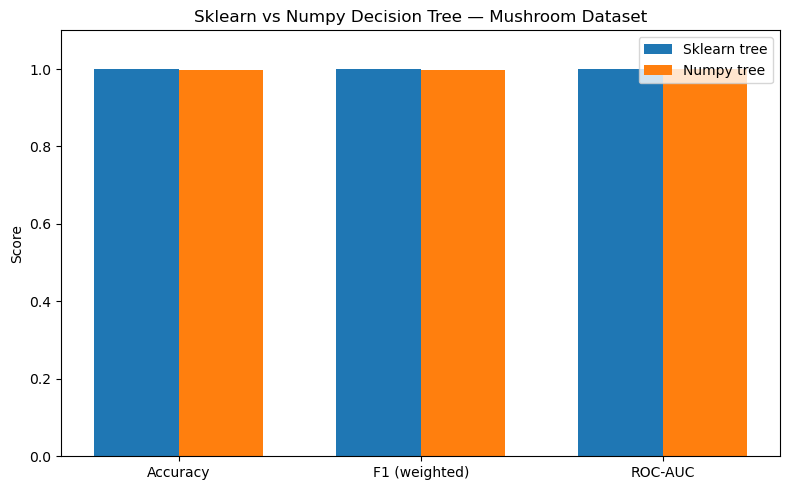

In [38]:
metrics = ["Accuracy", "F1 (weighted)", "ROC-AUC"]
sk_vals = [sk_acc, sk_f1, sk_auc]
np_vals = [np_acc, np_f1, np_auc]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, sk_vals, width, label="Sklearn tree")
ax.bar(x + width/2, np_vals, width, label="Numpy tree")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Sklearn vs Numpy Decision Tree — Mushroom Dataset")
ax.legend()
plt.tight_layout()
plt.savefig("comparison_bar.png", dpi=200, bbox_inches="tight")
plt.show()

In [39]:
def numpy_tree_node_count(node):
    if node is None: return 0
    if node.is_leaf: return 1
    return 1 + numpy_tree_node_count(node.left) + numpy_tree_node_count(node.right)

def numpy_tree_depth(node):
    if node is None: return 0
    if node.is_leaf: return 1
    return 1 + max(numpy_tree_depth(node.left), numpy_tree_depth(node.right))

np_root = best_numpy_tree.named_steps["model"]._model.root_
np_depth = numpy_tree_depth(np_root)
np_nodes = numpy_tree_node_count(np_root)

print(f"Numpy tree depth: {np_depth}")
print(f"Numpy tree nodes: {np_nodes}")

Numpy tree depth: 6
Numpy tree nodes: 23


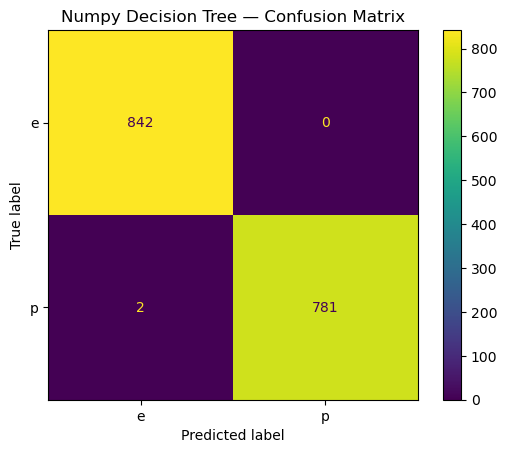

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test, np_pred)
plt.title("Numpy Decision Tree — Confusion Matrix")
plt.savefig("numpy_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## Conclusion

On the mushroom dataset, our numpy decision tree behaves almost the same as sklearn’s. Sklearn gets perfect scores (accuracy, F1, ROC-AUC all 1.0) and the numpy version comes very close, which shows a from-scratch numpy tree can basically replicate the core algorithm on this clean tabular data.

Both trees stay pretty shallow, which makes sense: the decision boundary is super clear and mostly driven by the odor feature. Any tiny differences are more about how they search for splits than about a mistake in the numpy implementation. So for this kind of neat categorical classification problem, a numpy-only decision tree is a totally viable alternative to sklearn.